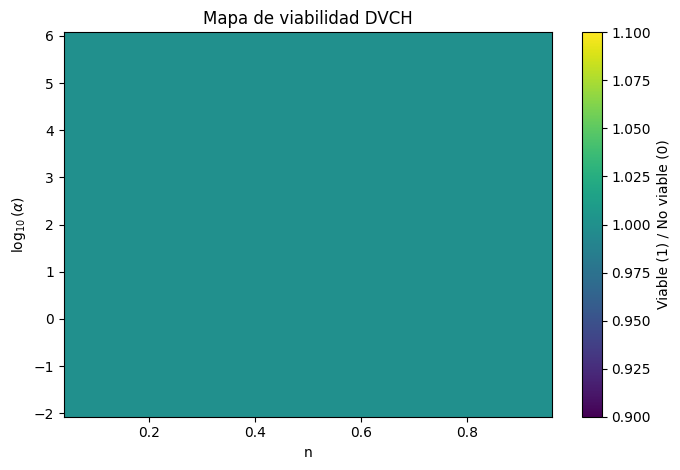

Fracción de región viable: 1.000


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros fijos
Om0 = 0.30
Or0 = 9e-5
Ol0 = 0.70
H0 = 70.0
c = 299792458.0
lpl = 1.616255e-35
H0_SI = H0 * 1000.0 / 3.085677581e22  # s^-1

z_grid = np.linspace(0.0, 5.0, 180)

# Reusa tu solver real aquí
def solve_dvch(z_array, Om0, Or0, Ol0, n, beta, tol=1e-8, max_iter=200):
    E = np.sqrt(np.maximum(Om0*(1+z_array)**3 + Or0*(1+z_array)**4 + Ol0/(1+beta), 1e-16))
    Om = Om0*(1+z_array)**3
    OL = Ol0*(Om/Om0)**n / (1.0 + beta*E**2)
    Qtilde = -(E*OL)/(1 + n*OL/np.maximum(Om,1e-14)) * (
        n - beta*(4*Or0*(1+z_array)**4 + 3*Om)/(3*(1+beta*E**2))
    )
    return E, Om, OL, Qtilde

def alpha_to_beta(alpha):
    return alpha * ((lpl * H0_SI / c)**2)

# Grilla
n_vals = np.linspace(0.05, 0.95, 45)
alpha_vals = np.logspace(-2, 6, 55)

viable = np.zeros((len(alpha_vals), len(n_vals)), dtype=int)

for ia, alpha in enumerate(alpha_vals):
    beta = alpha_to_beta(alpha)
    for jn, n in enumerate(n_vals):
        try:
            E, Om, OL, Q = solve_dvch(z_grid, Om0, Or0, Ol0, n, beta, tol=1e-8)

            cond_finite = np.all(np.isfinite(E)) and np.all(np.isfinite(Q))
            cond_positive = np.all(E**2 > 0)
            cond_transfer = np.all(Q < 0)  # criterio físico DVCH que mencionaste

            if cond_finite and cond_positive and cond_transfer:
                viable[ia, jn] = 1
        except Exception:
            viable[ia, jn] = 0

# Plot mapa
plt.figure(figsize=(7,4.8))
plt.pcolormesh(n_vals, np.log10(alpha_vals), viable, shading="auto", cmap="viridis")
plt.colorbar(label="Viable (1) / No viable (0)")
plt.xlabel("n")
plt.ylabel(r"$\log_{10}(\alpha)$")
plt.title("Mapa de viabilidad DVCH")
plt.tight_layout()
plt.savefig("fig_viability_map_n_alpha.png", dpi=300)
plt.show()

frac = viable.mean()
print(f"Fracción de región viable: {frac:.3f}")